# Support Vector Machine (SVM)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import time
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
print("SVM model ready for training")

SVM model ready for training


back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

e:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens\notebooks
E:\AI_ML\proj\sentiment-analysis-of-amazon-reviews-using-machine-learning-ml-queens


## Data Acquisition

load dataset

In [ ]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz')
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 50000)
y_train shape: (79972,)


In [6]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz')
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 50000)
y_valid shape: (20000,)


In [ ]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz')
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

## SVM Model Training (LinearSVC for efficiency)

In [ ]:
# Train LinearSVC (efficient for sparse data like TF-IDF)
# print("Training LinearSVC Classifier...")
# start_time = time.time()
# svm_classifier = LinearSVC(
#     C=1.0,  # Regularization parameter
#     loss='squared_hinge',  # Loss function
#     penalty='l2',  # Regularization type
#     max_iter=2000,  # Maximum iterations
#     random_state=42,
#     verbose=0,
#     dual='auto'
# )
# svm_classifier.fit(X_train_tfidf, y_train)
# training_time = time.time() - start_time
# print(f"Training completed in {training_time:.4f} seconds")

Training LinearSVC Classifier...
Training completed in 1.0309 seconds


In [10]:
# Train SVC (enormous amount of time and RAM)
print("Training LinearSVC Classifier...")
start_time = time.time()
svm_classifier = SVC(
    kernel='linear',
    # degree=3,  # Try 2, 3, 4, 5...
    C=1.0,  # Regularization parameter
    gamma='scale',
    # coef0=1.0,
    probability=True,
    max_iter=2000,  # Maximum iterations
    random_state=42,
    verbose=0,
)
svm_classifier.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.4f} seconds")

Training LinearSVC Classifier...
Training completed in 1673.6976 seconds


## Model Evaluation

In [12]:
# Make predictions
y_pred = svm_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("SVM (LinearSVC) CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {training_time:.4f} seconds")

SVM (LinearSVC) CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.8813
Precision: 0.8816
Recall:    0.8800
F1-Score:  0.8808
Training Time: 1.0309 seconds


## Classification Report

In [13]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      9966
    Positive       0.88      0.88      0.88     10034

    accuracy                           0.88     20000
   macro avg       0.88      0.88      0.88     20000
weighted avg       0.88      0.88      0.88     20000



## Confusion Matrix Visualization

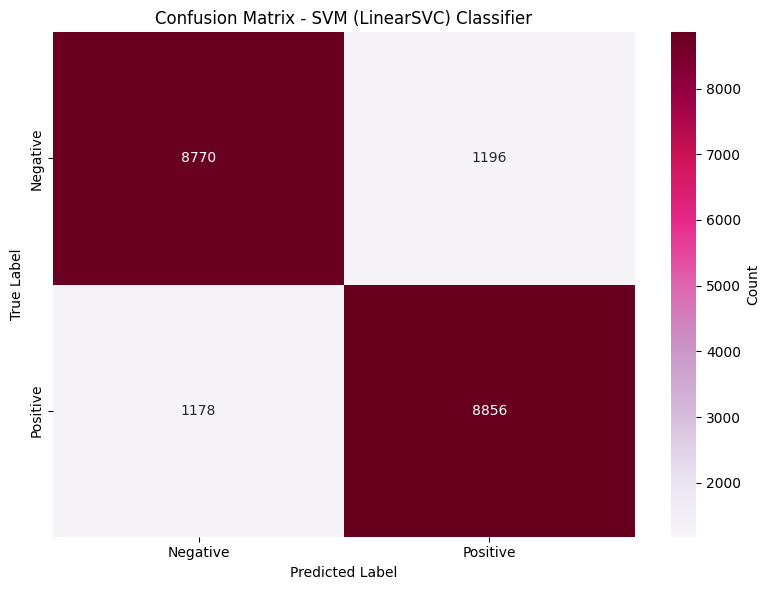

Confusion Matrix:
[[8770 1196]
 [1178 8856]]

True Negatives: 8770
False Positives: 1196
False Negatives: 1178
True Positives: 8856


In [14]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - SVM (LinearSVC) Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Feature Coefficients (SVM Weights)

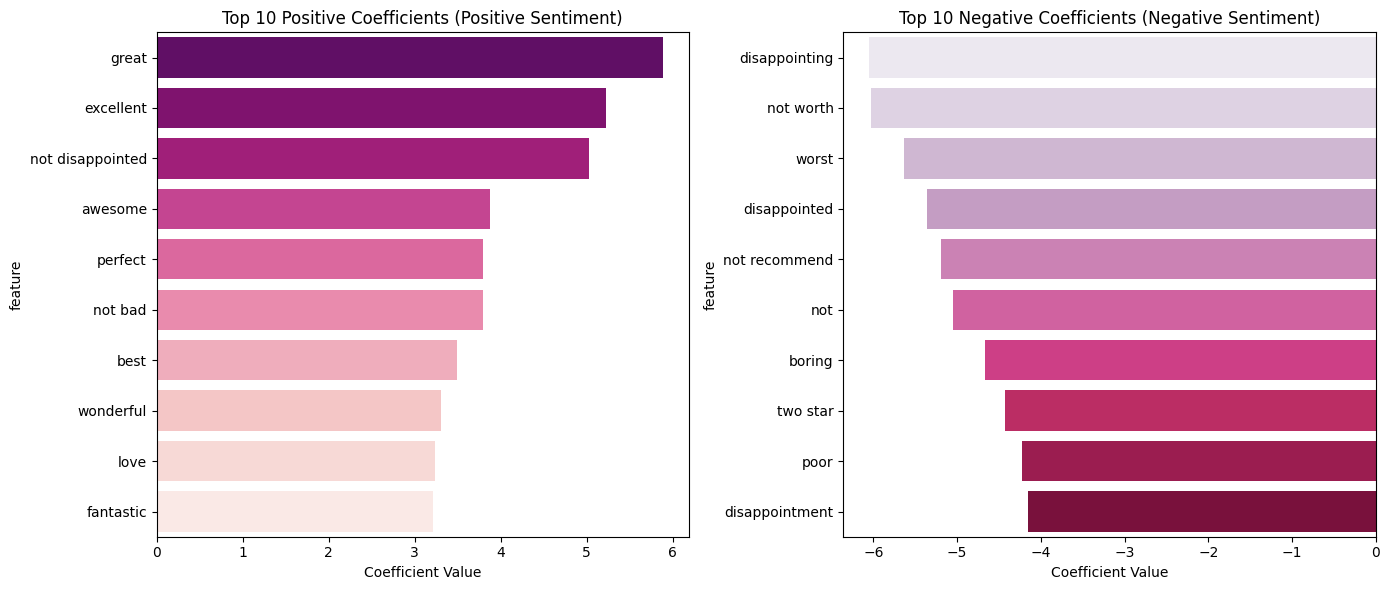


Top 10 Positive Coefficients (Positive Sentiment Indicators):
         feature  coefficient
           great     5.894676
       excellent     5.224650
not disappointed     5.030863
         awesome     3.882661
         perfect     3.799246
         not bad     3.794903
            best     3.490718
       wonderful     3.309783
            love     3.241559
       fantastic     3.212380

Top 10 Negative Coefficients (Negative Sentiment Indicators):
       feature  coefficient
 disappointing    -6.055570
     not worth    -6.033221
         worst    -5.640646
  disappointed    -5.360953
 not recommend    -5.198898
           not    -5.048491
        boring    -4.667120
      two star    -4.434197
          poor    -4.225797
disappointment    -4.156890


In [ ]:
# Get feature coefficients (weights)
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
# coefficients = svm_classifier.coef_[0]
coefficients = svm_classifier.coef_.toarray().flatten()
# Create DataFrame for better visualization
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})
# Get top positive and negative features
top_positive = coef_df.nlargest(10, 'coefficient')
top_negative = coef_df.nsmallest(10, 'coefficient')
# Plot top coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top_positive, x='coefficient', y='feature', palette='RdPu_r', ax=axes[0])
axes[0].set_title('Top 10 Positive Coefficients (Positive Sentiment)')
axes[0].set_xlabel('Coefficient Value')
sns.barplot(data=top_negative, x='coefficient', y='feature', palette='PuRd', ax=axes[1])
axes[1].set_title('Top 10 Negative Coefficients (Negative Sentiment)')
axes[1].set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('svm_feature_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 10 Positive Coefficients (Positive Sentiment Indicators):")
print(top_positive.to_string(index=False))
print("\nTop 10 Negative Coefficients (Negative Sentiment Indicators):")
print(top_negative.to_string(index=False))

## Decision Boundary Analysis

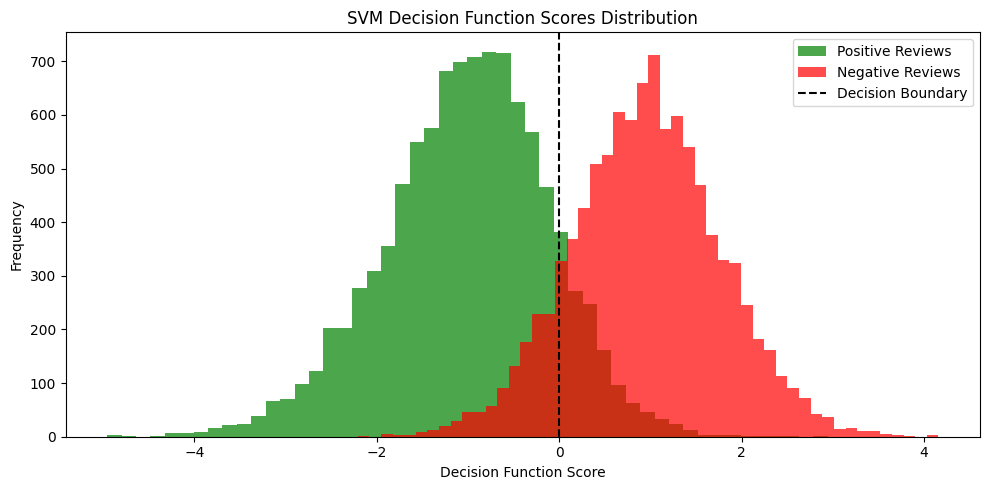


Decision Function Statistics:
Mean score for positive reviews: -1.0145
Mean score for negative reviews: 0.9533
Min decision score: -4.9545
Max decision score: 4.1583


In [19]:
# Get decision function scores
decision_scores = svm_classifier.decision_function(X_test_tfidf)
# Plot distribution of decision scores
plt.figure(figsize=(10, 5))
plt.hist(decision_scores[y_test == 1], bins=50, alpha=0.7, label='Positive Reviews', color='green')
plt.hist(decision_scores[y_test == 2], bins=50, alpha=0.7, label='Negative Reviews', color='red')
plt.axvline(0, color='black', linestyle='--', label='Decision Boundary')
plt.xlabel('Decision Function Score')
plt.ylabel('Frequency')
plt.title('SVM Decision Function Scores Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('svm_decision_scores.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nDecision Function Statistics:")
print(f"Mean score for positive reviews: {decision_scores[y_test == 1].mean():.4f}")
print(f"Mean score for negative reviews: {decision_scores[y_test == 2].mean():.4f}")
print(f"Min decision score: {decision_scores.min():.4f}")
print(f"Max decision score: {decision_scores.max():.4f}")

## Model Summary

In [20]:
print("SVM (LinearSVC) MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Kernel: Linear (implicit in LinearSVC)")
print(f"  - C (Regularization): {svm_classifier.C}")
print(f"  - Loss Function: hinge")
print(f"  - Penalty: L2")
print(f"  - Max Iterations: {svm_classifier.max_iter}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {training_time:.4f} seconds")
print(f"\nModel Characteristics:")
print(f"  - Type: LinearSVC (Support Vector Classification)")
print(f"  - Complexity: O(n × d) where n=samples, d=features")
print(f"  - Number of Coefficients: {len(coefficients)}")
print(f"  - Best for: High-dimensional sparse data (like TF-IDF)")
print(f"  - Margin-based Classifier: Maximizes decision boundary margin")

SVM (LinearSVC) MODEL SUMMARY

Model Parameters:
  - Kernel: Linear (implicit in LinearSVC)
  - C (Regularization): 1.0
  - Loss Function: hinge
  - Penalty: L2
  - Max Iterations: 2000

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.8813
  - Precision: 0.8816
  - Recall:    0.8800
  - F1-Score:  0.8808
  - Training Time: 1.0309 seconds

Model Characteristics:
  - Type: LinearSVC (Support Vector Classification)
  - Complexity: O(n × d) where n=samples, d=features
  - Number of Coefficients: 50000
  - Best for: High-dimensional sparse data (like TF-IDF)
  - Margin-based Classifier: Maximizes decision boundary margin
